# Structural Equation Modeling: A Practical Tutorial with R

## 1. What is Structural Equation Modeling?

Structural Equation Modeling, usually called **SEM**, is a statistical framework used to study relationships among multiple variables at the same time.

In ordinary regression, we usually ask a question like:

> Does X predict Y?

For example:

> Does stress predict depression score?

SEM allows us to ask a broader and more realistic question:

> How do several observed and unobserved variables relate to each other simultaneously?

For example:

> Does socioeconomic status influence stress, and does stress then influence depression?
> Are stress and depression measured through several questionnaire items rather than one direct variable?
> Is the effect of socioeconomic status on depression partly mediated through stress?

SEM is useful because many scientific concepts are not directly observed. Variables such as intelligence, resilience, depression, socioeconomic status, anxiety, wellbeing, cognitive ability, and biological vulnerability are often **latent constructs**. We observe them indirectly through questionnaire items, test scores, biomarkers, or behavioral measures.

SEM combines two ideas:

1. **Measurement model**
   This describes how observed variables measure latent variables.

2. **Structural model**
   This describes how latent or observed variables are related to each other.

A simple way to remember SEM is:

> SEM = factor analysis + regression/path analysis

The `lavaan` package is one of the most widely used open-source R packages for SEM. It supports confirmatory factor analysis, SEM, latent growth models, and related latent variable models. ([Journal of Statistical Software][1])

---

## 2. Why is SEM important?

SEM is important because many real-world research questions are not simple one-variable-to-one-variable problems.

In psychology, psychiatry, education, epidemiology, sociology, genetics, public health, and economics, researchers often work with complex systems. SEM helps model these systems in a structured way.

For example, suppose we are studying psychological resilience. We may believe that:

* family support improves resilience,
* resilience reduces depression,
* socioeconomic stress reduces resilience,
* depression is measured by several symptoms,
* resilience is measured by several questionnaire items.

A basic regression model may only test one part of this system. SEM allows us to test the full hypothesized structure.

SEM is especially useful when we want to:

* model latent variables,
* account for measurement error,
* test mediation,
* test direct and indirect effects,
* combine multiple regression equations,
* test whether a theoretical model fits the data,
* compare competing theoretical models.

This is why SEM is often used in fields where the theoretical structure matters as much as prediction.

---


## 3. Observed variables and latent variables

In SEM, variables are usually divided into two types.

### Observed variables

Observed variables are directly measured in the dataset.

Examples:

* age
* sex
* income
* PHQ-9 item scores
* test scores
* biomarker values
* questionnaire responses

In path diagrams, observed variables are usually shown as rectangles.

### Latent variables

Latent variables are not directly observed. They are inferred from multiple observed indicators.

Examples:

* depression
* anxiety
* resilience
* cognitive ability
* socioeconomic status
* inflammation
* wellbeing

In path diagrams, latent variables are usually shown as circles or ovals.

For example, depression may be measured using several questionnaire items:





In [1]:
depression =~ dep1 + dep2 + dep3 + dep4


Here, `depression` is a latent variable, and `dep1`, `dep2`, `dep3`, and `dep4` are observed indicators.

In `lavaan`, the operator `=~` defines a latent variable. The official lavaan SEM tutorial describes three core operators: `=~` for latent variable definitions, `~` for regressions, and `~~` for variances/covariances. ([Lavaan][2])

---




## 4. The two parts of SEM

### 4.1 Measurement model

The measurement model asks:

> Are my observed variables good indicators of the latent construct?

For example:

In [2]:
depression =~ dep1 + dep2 + dep3 + dep4
resilience =~ res1 + res2 + res3 + res4

This says that depression is measured by four depression items, and resilience is measured by four resilience items.

This part of SEM is closely related to **Confirmatory Factor Analysis**, or CFA. CFA is used when we already have a hypothesis about which observed variables measure which latent variables. lavaan provides the `cfa()` function for this purpose. ([Lavaan][3])

### 4.2 Structural model

The structural model asks:

> How are the latent variables related to each other?

For example:

In [3]:
depression ~ resilience + stress
resilience ~ social_support

depression ~ resilience + stress

resilience ~ social_support

This says:

* depression is predicted by resilience and stress,
* resilience is predicted by social support.

The structural part is like a system of regression models.

---

## 5. SEM syntax in lavaan

The basic syntax in `lavaan` is very readable.

### Latent variable definition

In [4]:
latent_variable =~ item1 + item2 + item3



Example:

In [5]:
depression =~ dep1 + dep2 + dep3


### Regression path

In [6]:
outcome ~ predictor


outcome ~ predictor

In [7]:
depression ~ stress + resilience



depression ~ stress + resilience

Example:

In [8]:




### Covariance


var1 ~~ var2

var1 ~ ~var2

Example:

In [9]:
stress ~~ social_support


### Variance


var1 ~~ var1


Example:


stress ~~ stress


stress ~ ~social_support

var1 ~ ~var1

Example:stress ~ ~stress



---

## 6. A simple SEM example

Let us create a simple example.

Suppose we are interested in three latent constructs:

1. **Stress**
2. **Resilience**
3. **Depression**

Each construct is measured by three observed questionnaire items.

We hypothesize that:

* stress increases depression,
* resilience reduces depression,
* stress reduces resilience,
* resilience partially mediates the effect of stress on depression.

The conceptual model is:

```text
Stress  →  Resilience  →  Depression
   └──────────────────→  Depression
```

This means stress may affect depression directly and indirectly through resilience.

---

In [10]:
## 7. Complete R script using lavaan


# ============================================================
# Structural Equation Modeling Tutorial using lavaan
# ============================================================

# Install packages if needed
# install.packages("lavaan")
 install.packages("semPlot")
# install.packages("MASS")

library(lavaan)
library(semPlot)
library(MASS)

set.seed(123)

# ------------------------------------------------------------
# 1. Simulate synthetic data
# ------------------------------------------------------------

n <- 500

# Simulate latent variables
stress_latent <- rnorm(n, mean = 0, sd = 1)

resilience_latent <- -0.5 * stress_latent + rnorm(n, mean = 0, sd = 0.8)

depression_latent <- 0.6 * stress_latent - 0.7 * resilience_latent +
  rnorm(n, mean = 0, sd = 0.8)

# Create observed indicators with measurement error
data_sem <- data.frame(
  stress1 = 0.8 * stress_latent + rnorm(n, 0, 0.4),
  stress2 = 0.7 * stress_latent + rnorm(n, 0, 0.5),
  stress3 = 0.9 * stress_latent + rnorm(n, 0, 0.4),

  resil1 = 0.8 * resilience_latent + rnorm(n, 0, 0.4),
  resil2 = 0.7 * resilience_latent + rnorm(n, 0, 0.5),
  resil3 = 0.9 * resilience_latent + rnorm(n, 0, 0.4),

  dep1 = 0.8 * depression_latent + rnorm(n, 0, 0.4),
  dep2 = 0.7 * depression_latent + rnorm(n, 0, 0.5),
  dep3 = 0.9 * depression_latent + rnorm(n, 0, 0.4)
)

head(data_sem)
summary(data_sem)

Installing package into ‘/Users/nbhadra/Library/R/arm64/4.3/library’
(as ‘lib’ is unspecified)




The downloaded binary packages are in
	/var/folders/3f/6pzn2nyn32d7wthyxkzsqyxcdrtvym/T//Rtmp96VAjk/downloaded_packages


Warning message:
“package ‘lavaan’ was built under R version 4.3.3”
This is lavaan 0.6-19
lavaan is FREE software! Please report any bugs.



,stress1,stress2,stress3,resil1,resil2,resil3,dep1,dep2,dep3
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,-0.7767752,-0.6481348,-0.77595113,-0.22114415,0.5982737,-0.102528898,-0.4598761,-0.94150853,-1.43572002
2,-0.3070449,-0.0426553,0.02256535,-0.67499896,-1.1793024,-0.351837840,-0.6746907,0.21788373,-0.96182442
3,0.8861274,0.8203012,1.12103167,-0.54560701,-0.9125343,0.306268174,1.2368075,0.05049758,0.19536724
4,0.3072342,0.6589697,-0.15013607,0.17356204,0.2572333,-0.004627744,-0.7595522,0.41896327,-0.06974591
5,0.5515722,0.1775694,0.42611280,0.02181441,-0.6751701,-1.955223221,-0.5580200,-0.29196672,-1.45021286
6,2.2229374,0.8929113,1.35330993,-0.76188637,-0.7179487,0.041845017,2.5151611,1.92810266,2.51116992


    stress1            stress2             stress3             resil1        
 Min.   :-2.68041   Min.   :-2.691356   Min.   :-2.64489   Min.   :-2.82284  
 1st Qu.:-0.54070   1st Qu.:-0.543447   1st Qu.:-0.53635   1st Qu.:-0.64442  
 Median : 0.06657   Median :-0.029942   Median : 0.04875   Median : 0.01097  
 Mean   : 0.05116   Mean   :-0.007807   Mean   : 0.04066   Mean   :-0.02437  
 3rd Qu.: 0.57855   3rd Qu.: 0.524629   3rd Qu.: 0.61250   3rd Qu.: 0.53320  
 Max.   : 2.78049   Max.   : 2.680151   Max.   : 3.15869   Max.   : 2.26858  
     resil2             resil3              dep1                dep2         
 Min.   :-2.42576   Min.   :-3.19028   Min.   :-3.012669   Min.   :-2.59815  
 1st Qu.:-0.59795   1st Qu.:-0.66951   1st Qu.:-0.761669   1st Qu.:-0.62917  
 Median : 0.04993   Median :-0.02788   Median : 0.006298   Median : 0.01076  
 Mean   :-0.01127   Mean   :-0.03598   Mean   : 0.037102   Mean   : 0.04762  
 3rd Qu.: 0.52862   3rd Qu.: 0.59763   3rd Qu.: 0.785262   3rd Q

---

## 8. Define the SEM model


In [11]:

# ------------------------------------------------------------
# 2. Define SEM model
# ------------------------------------------------------------

model_sem <- '

  # Measurement model
  stress =~ stress1 + stress2 + stress3
  resilience =~ resil1 + resil2 + resil3
  depression =~ dep1 + dep2 + dep3

  # Structural model
  resilience ~ a * stress
  depression ~ b * resilience + c * stress

  # Indirect, direct, and total effects
  indirect := a * b
  direct := c
  total := c + (a * b)

'



In this model:

In [12]:
stress =~ stress1 + stress2 + stress3

means that the latent variable `stress` is measured by three observed items.


In [13]:
resilience ~ a * stress


resilience ~ a * stress

means that stress predicts resilience. The path coefficient is labeled `a`.


In [14]:
depression ~ b * resilience + c * stress


depression ~ b * resilience + c * stress


means that depression is predicted by both resilience and stress. The path from resilience to depression is labeled `b`, and the direct path from stress to depression is labeled `c`.

The indirect effect is calculated as:

indirect := a * b


This represents:


---

## 9. Fit the SEM model



```text
stress → resilience → depression
```

In [15]:
# ------------------------------------------------------------
# 3. Fit the model
# ------------------------------------------------------------

fit_sem <- sem(
  model_sem,
  data = data_sem,
  meanstructure = TRUE
)

summary(
  fit_sem,
  fit.measures = TRUE,
  standardized = TRUE,
  rsquare = TRUE
)

,lhs,op,rhs,label,exo,est,se,z,pvalue,std.lv,std.all
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,stress,=~,stress1,,0,1.000000000,0.00000000,NA,NA,0.743305042,0.868605970
2,stress,=~,stress2,,0,0.888712566,0.03965218,22.4127048,0.000000e+00,0.660584531,0.807109561
3,stress,=~,stress3,,0,1.165333138,0.04332610,26.8967905,0.000000e+00,0.866197997,0.917815829
4,resilience,=~,resil1,,0,1.000000000,0.00000000,NA,NA,0.771457415,0.896166093
5,resilience,=~,resil2,,0,0.851920295,0.03685346,23.1164239,0.000000e+00,0.657220229,0.803459938
6,resilience,=~,resil3,,0,1.123935553,0.04011596,28.0171692,0.000000e+00,0.867068417,0.905885416
7,depression,=~,dep1,,0,1.000000000,0.00000000,NA,NA,1.115486326,0.939423104
8,depression,=~,dep2,,0,0.852686146,0.02485828,34.3018961,0.000000e+00,0.951159737,0.891874563
9,depression,=~,dep3,,0,1.146769075,0.02726355,42.0623568,0.000000e+00,1.279205223,0.950922084


The `sem()` function fits the structural equation model. The argument `standardized = TRUE` gives standardized estimates, which are often easier to interpret.

---

## 10. Understanding the output

The output contains several important parts.

### 10.1 Factor loadings

Factor loadings show how strongly each observed item measures its latent construct.

Example:

```text
stress =~
  stress1
  stress2
  stress3
```

If the standardized loading of `stress1` is 0.85, it means `stress1` is a strong indicator of the latent stress factor.

A rough interpretation:

| Standardized loading | Interpretation |
| -------------------- | -------------- |
| 0.30                 | weak           |
| 0.50                 | moderate       |
| 0.70 or higher       | strong         |

These are only rough guidelines. Interpretation depends on the field and measurement instrument.

### 10.2 Regression paths

The structural paths tell us how latent variables predict each other.

Example:

```text
resilience ~ stress
depression ~ resilience + stress
```

If the standardized coefficient from stress to resilience is negative, it means higher stress is associated with lower resilience.

If the coefficient from resilience to depression is negative, it means higher resilience is associated with lower depression.

If the coefficient from stress to depression is positive, it means higher stress is associated with higher depression.

### 10.3 R-squared values

R-squared tells us how much variance is explained in each endogenous variable.

For example:

```text
R2 for resilience = 0.25
R2 for depression = 0.60
```

This means:

* 25% of the variance in resilience is explained by stress,
* 60% of the variance in depression is explained by stress and resilience.

---

## 11. Model fit indices

SEM does not only estimate coefficients. It also asks:

> Does the proposed model reproduce the observed covariance structure reasonably well?

This is one of the key differences between SEM and ordinary regression.

Common fit indices include:

### Chi-square test

The chi-square test evaluates exact model fit.

A significant chi-square suggests that the model-implied covariance matrix differs from the observed covariance matrix.

However, chi-square is sensitive to sample size. With large samples, even small misfit can become statistically significant.

### CFI: Comparative Fit Index

CFI compares the proposed model with a baseline model.

Common rough guidelines:

* CFI > 0.90: acceptable
* CFI > 0.95: good

### TLI: Tucker-Lewis Index

TLI is similar to CFI but penalizes model complexity.

Common rough guidelines:

* TLI > 0.90: acceptable
* TLI > 0.95: good

### RMSEA: Root Mean Square Error of Approximation

RMSEA measures approximate fit.

Common rough guidelines:

* RMSEA < 0.08: acceptable
* RMSEA < 0.05: good

### SRMR: Standardized Root Mean Square Residual

SRMR measures the average standardized difference between observed and predicted correlations.

Common rough guidelines:

* SRMR < 0.08: acceptable

These cutoffs should not be used mechanically. They are guidelines, not universal rules.



You can extract fit measures in R:


In [16]:
fitMeasures(
  fit_sem,
  c("chisq", "df", "pvalue", "cfi", "tli", "rmsea", "srmr")
)

chisq     df pvalue    cfi    tli  rmsea   srmr 
39.593 24.000  0.024  0.996  0.994  0.036  0.020


---

## 12. Visualize the SEM model

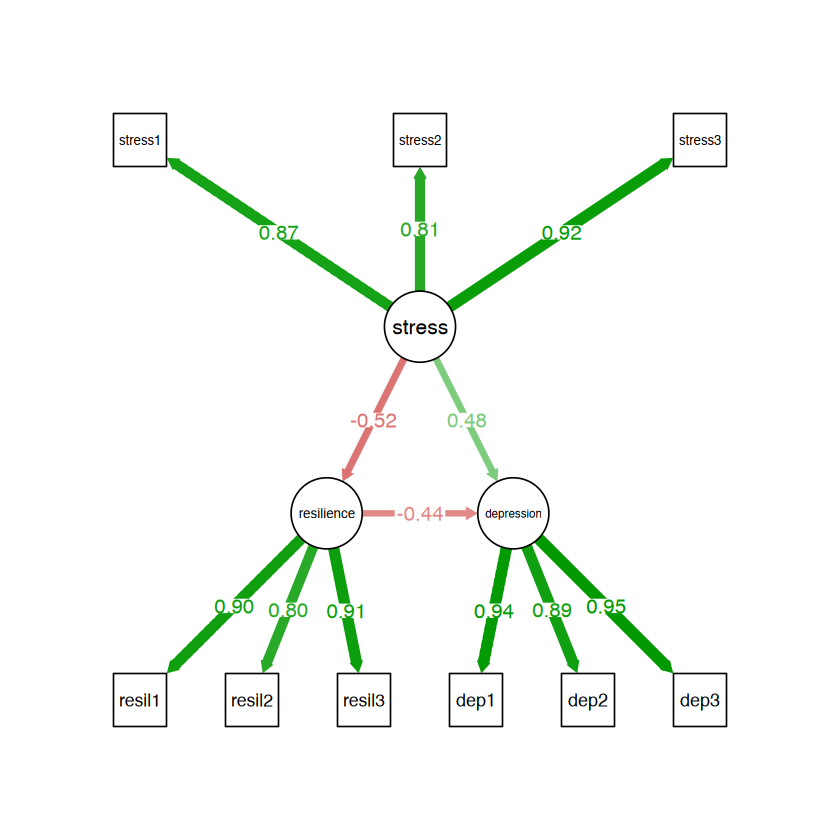

In [17]:
# ------------------------------------------------------------
# 4. Plot the SEM model
# ------------------------------------------------------------

semPaths(
  fit_sem,
  what = "std",
  layout = "tree",
  edge.label.cex = 1.0,
  sizeMan = 6,
  sizeLat = 8,
  residuals = FALSE,
  intercepts = FALSE,
  nCharNodes = 0
)

This creates a path diagram.

In the diagram:

* circles represent latent variables,
* rectangles represent observed variables,
* arrows represent regression or measurement paths,
* numbers on arrows are usually standardized coefficients.

---

## 13. Mediation in SEM

One of the most useful applications of SEM is mediation analysis.

In our example:

```text
stress → resilience → depression
```

This means stress may affect depression indirectly through resilience.

The indirect effect is:

indirect := a * b



Where:

* `a` = effect of stress on resilience,
* `b` = effect of resilience on depression.

The total effect is:

total := direct + indirect


In lavaan:

In [18]:
parameterEstimates(
  fit_sem,
  standardized = TRUE
)

lhs,op,rhs,label,est,se,z,pvalue,ci.lower,ci.upper,std.lv,std.all
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
stress,=~,stress1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.743305042,0.868605970
stress,=~,stress2,,0.888712566,0.03965218,22.4127048,0.000000e+00,0.81099572,0.96642941,0.660584531,0.807109561
stress,=~,stress3,,1.165333138,0.04332610,26.8967905,0.000000e+00,1.08041554,1.25025074,0.866197997,0.917815829
resilience,=~,resil1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.771457415,0.896166093
resilience,=~,resil2,,0.851920295,0.03685346,23.1164239,0.000000e+00,0.77968883,0.92415176,0.657220229,0.803459938
resilience,=~,resil3,,1.123935553,0.04011596,28.0171692,0.000000e+00,1.04530972,1.20256138,0.867068417,0.905885416
depression,=~,dep1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,1.115486326,0.939423104
depression,=~,dep2,,0.852686146,0.02485828,34.3018961,0.000000e+00,0.80396481,0.90140748,0.951159737,0.891874563
depression,=~,dep3,,1.146769075,0.02726355,42.0623568,0.000000e+00,1.09333350,1.20020465,1.279205223,0.950922084


This will show the direct, indirect, and total effects.

---

## 14. Bootstrapped confidence intervals for indirect effects

Indirect effects often have non-normal sampling distributions. Bootstrapping is commonly used for mediation.


In [19]:
fit_sem_boot <- sem(
  model_sem,
  data = data_sem,
  se = "bootstrap",
  bootstrap = 1000,
  meanstructure = TRUE
)

parameterEstimates(
  fit_sem_boot,
  boot.ci.type = "perc",
  standardized = TRUE
)

lhs,op,rhs,label,est,se,z,pvalue,ci.lower,ci.upper,std.lv,std.all
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
stress,=~,stress1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.743305042,0.868605970
stress,=~,stress2,,0.888712566,0.03875278,22.9328715,0.000000e+00,0.81296490,0.96278456,0.660584531,0.807109561
stress,=~,stress3,,1.165333138,0.04330515,26.9098040,0.000000e+00,1.08137123,1.25711142,0.866197997,0.917815829
resilience,=~,resil1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.771457415,0.896166093
resilience,=~,resil2,,0.851920295,0.03808626,22.3681820,0.000000e+00,0.77898450,0.92590202,0.657220229,0.803459938
resilience,=~,resil3,,1.123935553,0.04317346,26.0330200,0.000000e+00,1.04008005,1.21317797,0.867068417,0.905885416
depression,=~,dep1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,1.115486326,0.939423104
depression,=~,dep2,,0.852686146,0.02355667,36.1972280,0.000000e+00,0.80457833,0.89658444,0.951159737,0.891874563
depression,=~,dep3,,1.146769075,0.02873547,39.9077899,0.000000e+00,1.09159357,1.20370831,1.279205223,0.950922084


This gives bootstrap confidence intervals for the indirect effect.

If the confidence interval for the indirect effect does not include zero, that supports evidence for mediation.

---

## 15. CFA before SEM

In practice, it is often useful to first fit the measurement model alone.

In [20]:
# ------------------------------------------------------------
# 5. Confirmatory Factor Analysis first
# ------------------------------------------------------------

model_cfa <- '

  stress =~ stress1 + stress2 + stress3
  resilience =~ resil1 + resil2 + resil3
  depression =~ dep1 + dep2 + dep3

'

fit_cfa <- cfa(
  model_cfa,
  data = data_sem,
  meanstructure = TRUE
)

summary(
  fit_cfa,
  fit.measures = TRUE,
  standardized = TRUE
)

,lhs,op,rhs,exo,est,se,z,pvalue,std.lv,std.all
,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,stress,=~,stress1,0,1.000000000,0.00000000,NA,NA,0.743304970,0.86860600
2,stress,=~,stress2,0,0.888712491,0.03965218,22.4127035,0.000000e+00,0.660584412,0.80710955
3,stress,=~,stress3,0,1.165332895,0.04332610,26.8967848,0.000000e+00,0.866197733,0.91781573
4,resilience,=~,resil1,0,1.000000000,0.00000000,NA,NA,0.771457341,0.89616610
5,resilience,=~,resil2,0,0.851920122,0.03685347,23.1164167,0.000000e+00,0.657220032,0.80345979
6,resilience,=~,resil3,0,1.123935775,0.04011596,28.0171702,0.000000e+00,0.867068504,0.90588546
7,depression,=~,dep1,0,1.000000000,0.00000000,NA,NA,1.115486234,0.93942308
8,depression,=~,dep2,0,0.852686291,0.02485828,34.3018972,0.000000e+00,0.951159819,0.89187460
9,depression,=~,dep3,0,1.146769204,0.02726356,42.0623465,0.000000e+00,1.279205260,0.95092205


This checks whether the measurement structure is reasonable before adding structural paths.

A good workflow is:

```text
Step 1: Check the measurement model using CFA
Step 2: Check reliability and factor loadings
Step 3: Fit the full SEM model
Step 4: Interpret direct, indirect, and total effects
Step 5: Report model fit and standardized estimates
```

---

## 16. SEM versus regression

Regression and SEM are related, but SEM is more general.

| Feature            | Regression                   | SEM                 |
| ------------------ | ---------------------------- | ------------------- |
| Observed variables | Yes                          | Yes                 |
| Latent variables   | No                           | Yes                 |
| Multiple outcomes  | Limited                      | Yes                 |
| Measurement error  | Usually ignored              | Explicitly modeled  |
| Mediation          | Possible                     | Natural framework   |
| Model fit          | Usually not covariance-based | Central part of SEM |
| Theory testing     | Limited                      | Strong              |

Regression is often enough when the research question is simple and variables are directly observed.

SEM is useful when:

* constructs are latent,
* measurement error matters,
* several equations are needed,
* mediation is central,
* theory structure is important.

---

## 17. Assumptions of SEM

SEM has assumptions that should be considered carefully.

### 17.1 Correct model specification

The model should be theoretically justified. SEM can test whether a model is consistent with data, but it cannot prove that the model is true.

A good-fitting model is not necessarily the only good-fitting model.

### 17.2 Adequate sample size

SEM usually requires moderate to large sample sizes.

There is no single universal rule, but small samples can lead to unstable estimates, convergence problems, or unreliable fit indices.

### 17.3 Multivariate normality

Classical SEM often assumes multivariate normality, especially with maximum likelihood estimation.

If variables are non-normal, robust estimators can be used.











Example:








In [21]:
fit_robust <- sem(
  model_sem,
  data = data_sem,
  estimator = "MLR",
  meanstructure = TRUE
)

summary(
  fit_robust,
  fit.measures = TRUE,
  standardized = TRUE
)

,lhs,op,rhs,label,exo,est,se,z,pvalue,std.lv,std.all
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,stress,=~,stress1,,0,1.000000000,0.00000000,NA,NA,0.743305042,0.868605970
2,stress,=~,stress2,,0,0.888712566,0.03942880,22.5396804,0.000000e+00,0.660584531,0.807109561
3,stress,=~,stress3,,0,1.165333138,0.04482736,25.9960266,0.000000e+00,0.866197997,0.917815829
4,resilience,=~,resil1,,0,1.000000000,0.00000000,NA,NA,0.771457415,0.896166093
5,resilience,=~,resil2,,0,0.851920295,0.03803463,22.3985404,0.000000e+00,0.657220229,0.803459938
6,resilience,=~,resil3,,0,1.123935553,0.04081111,27.5399390,0.000000e+00,0.867068417,0.905885416
7,depression,=~,dep1,,0,1.000000000,0.00000000,NA,NA,1.115486326,0.939423104
8,depression,=~,dep2,,0,0.852686146,0.02411456,35.3598025,0.000000e+00,0.951159737,0.891874563
9,depression,=~,dep3,,0,1.146769075,0.02812917,40.7679698,0.000000e+00,1.279205223,0.950922084


`MLR` provides robust standard errors and a robust test statistic.

### 17.4 Missing data

SEM can handle missing data using full information maximum likelihood.



In [22]:
fit_missing <- sem(
  model_sem,
  data = data_sem,
  missing = "fiml",
  meanstructure = TRUE
)

This is often preferable to simply deleting all rows with missing values, assuming the missing data mechanism is appropriate.


---

## 18. Modification indices

Modification indices suggest possible model changes that may improve fit.

In [23]:
modindices(
  fit_sem,
  sort = TRUE,
  minimum.value = 10
)

,lhs,op,rhs,mi,epc,sepc.lv,sepc.all,sepc.nox
,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
66,stress2,~~,stress3,15.32568,-0.08218576,-0.08218576,-0.4539352,-0.4539352
52,depression,=~,stress1,15.31238,-0.13934818,-0.15544099,-0.1816441,-0.1816441



However, modification indices should be used cautiously.

You should not blindly add paths just because they improve model fit. Every added path should have theoretical justification.

Otherwise, the model becomes data-driven and may not replicate.



---

## 19. Reporting SEM results

A clear SEM report should include:

1. The theoretical model
2. Description of observed indicators
3. Estimator used
4. Sample size
5. Model fit indices
6. Standardized factor loadings
7. Structural path coefficients
8. Direct, indirect, and total effects if mediation is tested
9. Any model modifications
10. Limitations

Example reporting paragraph:

> We fitted a structural equation model to examine whether resilience mediated the association between stress and depression. Stress, resilience, and depression were modeled as latent variables, each measured by three observed indicators. The model showed acceptable fit according to CFI, TLI, RMSEA, and SRMR. Standardized path estimates indicated that higher stress was associated with lower resilience, and higher resilience was associated with lower depression. The indirect effect from stress to depression through resilience was estimated using bootstrapped confidence intervals.




---

## 20. Common mistakes in SEM

### Mistake 1: Treating SEM as causal proof

SEM can represent causal hypotheses, but it does not prove causality by itself. Causal interpretation depends on design, theory, temporal ordering, confounding control, and assumptions.

### Mistake 2: Ignoring the measurement model

If the latent variables are poorly measured, the structural paths may not be meaningful.

### Mistake 3: Chasing fit indices

Good fit indices do not guarantee that the model is scientifically meaningful.

### Mistake 4: Overfitting with modification indices

Adding many paths based only on modification indices can make the model fit the current dataset but fail in future datasets.

### Mistake 5: Reporting only p-values

SEM results should include effect sizes, standardized estimates, confidence intervals, and model fit indices.

---


,lhs,op,rhs,label,exo,est,se,z,pvalue,std.lv,std.all
,<chr>,<chr>,<chr>,<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,stress,=~,stress1,,0,1.000000000,0.00000000,NA,NA,0.743305042,0.868605970
2,stress,=~,stress2,,0,0.888712566,0.03965218,22.4127048,0.000000e+00,0.660584531,0.807109561
3,stress,=~,stress3,,0,1.165333138,0.04332610,26.8967905,0.000000e+00,0.866197997,0.917815829
4,resilience,=~,resil1,,0,1.000000000,0.00000000,NA,NA,0.771457415,0.896166093
5,resilience,=~,resil2,,0,0.851920295,0.03685346,23.1164239,0.000000e+00,0.657220229,0.803459938
6,resilience,=~,resil3,,0,1.123935553,0.04011596,28.0171692,0.000000e+00,0.867068417,0.905885416
7,depression,=~,dep1,,0,1.000000000,0.00000000,NA,NA,1.115486326,0.939423104
8,depression,=~,dep2,,0,0.852686146,0.02485828,34.3018961,0.000000e+00,0.951159737,0.891874563
9,depression,=~,dep3,,0,1.146769075,0.02726355,42.0623568,0.000000e+00,1.279205223,0.950922084


chisq     df pvalue    cfi    tli  rmsea   srmr 
39.593 24.000  0.024  0.996  0.994  0.036  0.020

lhs,op,rhs,label,est,se,z,pvalue,ci.lower,ci.upper,std.lv,std.all
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
stress,=~,stress1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.743305042,0.868605970
stress,=~,stress2,,0.888712566,0.03965218,22.4127048,0.000000e+00,0.81099572,0.96642941,0.660584531,0.807109561
stress,=~,stress3,,1.165333138,0.04332610,26.8967905,0.000000e+00,1.08041554,1.25025074,0.866197997,0.917815829
resilience,=~,resil1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.771457415,0.896166093
resilience,=~,resil2,,0.851920295,0.03685346,23.1164239,0.000000e+00,0.77968883,0.92415176,0.657220229,0.803459938
resilience,=~,resil3,,1.123935553,0.04011596,28.0171692,0.000000e+00,1.04530972,1.20256138,0.867068417,0.905885416
depression,=~,dep1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,1.115486326,0.939423104
depression,=~,dep2,,0.852686146,0.02485828,34.3018961,0.000000e+00,0.80396481,0.90140748,0.951159737,0.891874563
depression,=~,dep3,,1.146769075,0.02726355,42.0623568,0.000000e+00,1.09333350,1.20020465,1.279205223,0.950922084


lhs,op,rhs,label,est,se,z,pvalue,ci.lower,ci.upper,std.lv,std.all
<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
stress,=~,stress1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.743305042,0.868605970
stress,=~,stress2,,0.888712566,0.03875278,22.9328715,0.000000e+00,0.81296490,0.96278456,0.660584531,0.807109561
stress,=~,stress3,,1.165333138,0.04330515,26.9098040,0.000000e+00,1.08137123,1.25711142,0.866197997,0.917815829
resilience,=~,resil1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,0.771457415,0.896166093
resilience,=~,resil2,,0.851920295,0.03808626,22.3681820,0.000000e+00,0.77898450,0.92590202,0.657220229,0.803459938
resilience,=~,resil3,,1.123935553,0.04317346,26.0330200,0.000000e+00,1.04008005,1.21317797,0.867068417,0.905885416
depression,=~,dep1,,1.000000000,0.00000000,NA,NA,1.00000000,1.00000000,1.115486326,0.939423104
depression,=~,dep2,,0.852686146,0.02355667,36.1972280,0.000000e+00,0.80457833,0.89658444,0.951159737,0.891874563
depression,=~,dep3,,1.146769075,0.02873547,39.9077899,0.000000e+00,1.09159357,1.20370831,1.279205223,0.950922084


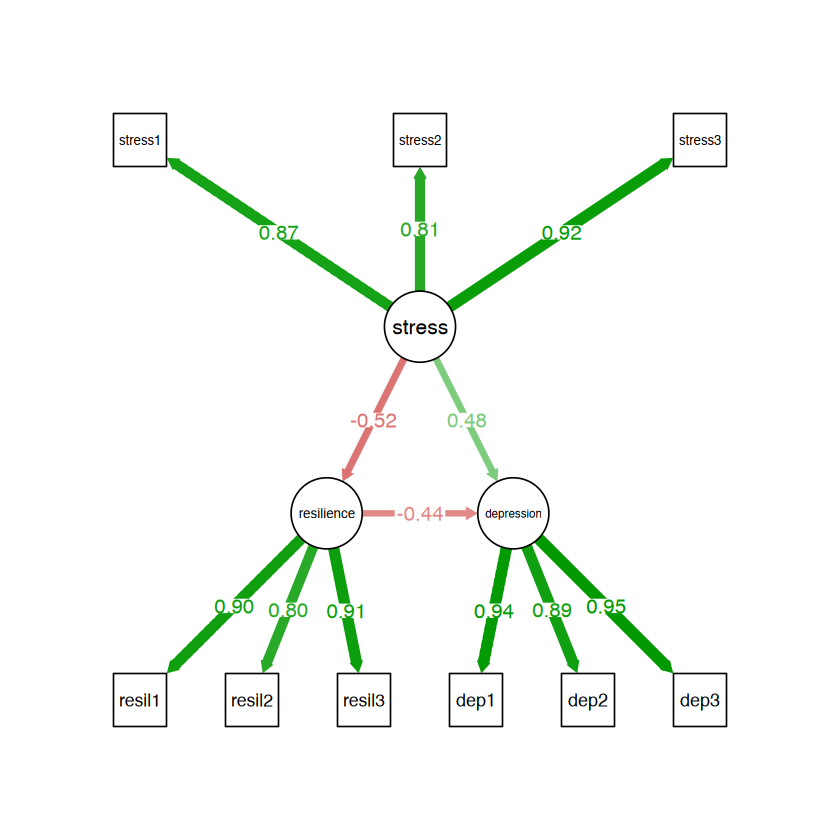

In [24]:
## 21. Full R code in one block


# ============================================================
# Full SEM Tutorial Script
# ============================================================

library(lavaan)
library(semPlot)
library(MASS)

set.seed(123)

n <- 500

stress_latent <- rnorm(n, 0, 1)

resilience_latent <- -0.5 * stress_latent + rnorm(n, 0, 0.8)

depression_latent <- 0.6 * stress_latent -
  0.7 * resilience_latent +
  rnorm(n, 0, 0.8)

data_sem <- data.frame(
  stress1 = 0.8 * stress_latent + rnorm(n, 0, 0.4),
  stress2 = 0.7 * stress_latent + rnorm(n, 0, 0.5),
  stress3 = 0.9 * stress_latent + rnorm(n, 0, 0.4),

  resil1 = 0.8 * resilience_latent + rnorm(n, 0, 0.4),
  resil2 = 0.7 * resilience_latent + rnorm(n, 0, 0.5),
  resil3 = 0.9 * resilience_latent + rnorm(n, 0, 0.4),

  dep1 = 0.8 * depression_latent + rnorm(n, 0, 0.4),
  dep2 = 0.7 * depression_latent + rnorm(n, 0, 0.5),
  dep3 = 0.9 * depression_latent + rnorm(n, 0, 0.4)
)

model_sem <- '

  # Measurement model
  stress =~ stress1 + stress2 + stress3
  resilience =~ resil1 + resil2 + resil3
  depression =~ dep1 + dep2 + dep3

  # Structural model
  resilience ~ a * stress
  depression ~ b * resilience + c * stress

  # Effects
  indirect := a * b
  direct := c
  total := c + (a * b)

'

fit_sem <- sem(
  model_sem,
  data = data_sem,
  meanstructure = TRUE
)

summary(
  fit_sem,
  fit.measures = TRUE,
  standardized = TRUE,
  rsquare = TRUE
)

fitMeasures(
  fit_sem,
  c("chisq", "df", "pvalue", "cfi", "tli", "rmsea", "srmr")
)

parameterEstimates(
  fit_sem,
  standardized = TRUE
)

semPaths(
  fit_sem,
  what = "std",
  layout = "tree",
  edge.label.cex = 1.0,
  sizeMan = 6,
  sizeLat = 8,
  residuals = FALSE,
  intercepts = FALSE,
  nCharNodes = 0
)

fit_sem_boot <- sem(
  model_sem,
  data = data_sem,
  se = "bootstrap",
  bootstrap = 1000,
  meanstructure = TRUE
)

parameterEstimates(
  fit_sem_boot,
  boot.ci.type = "perc",
  standardized = TRUE
)




---

## 22. Final takeaway

Structural Equation Modeling is a powerful method for studying complex relationships among observed and latent variables. It is especially useful when a research question involves measurement error, latent constructs, mediation, and multiple pathways.

A good SEM analysis should not start from software. It should start from theory.

The main question is not only:

> Which paths are significant?

A better question is:

> Does this theoretical model provide a reasonable and interpretable explanation of the observed data?

SEM is strongest when statistical modeling, measurement quality, and domain theory are used together.



---

## References

Rosseel, Y. (2012). *lavaan: An R Package for Structural Equation Modeling*. Journal of Statistical Software, 48(2), 1–36.

Official lavaan tutorials: [https://lavaan.ugent.be/tutorial/](https://lavaan.ugent.be/tutorial/)

Kline, R. B. *Principles and Practice of Structural Equation Modeling*.

[1]: https://www.jstatsoft.org/v48/i02/?utm_source=chatgpt.com "lavaan: An R Package for Structural Equation Modeling"
[2]: https://lavaan.ugent.be/tutorial/sem.html?utm_source=chatgpt.com "A SEM example"
[3]: https://lavaan.ugent.be/tutorial/cfa.html?utm_source=chatgpt.com "A CFA example"
